# From DICOM to a Generalized Research Dataset
### Companion notebook — *From Pixels to Patients*, AAPM 2026 (Session 1 of 3)

**Brian M. Anderson, PhD** · Radiation Medicine & Applied Sciences

This notebook is the runnable companion to the talk. It takes the public
**NSCLC-Radiomics** collection from **TCIA** and walks the full pipeline the slides
describe, using [**DicomRTTool**](https://github.com/brianmanderson/Dicom_RT_and_Images_to_Mask):

1. **Download** a handful of NSCLC-Radiomics patients (CT + RTSTRUCT) from TCIA.
2. **Discover** every series and the ROIs present.
3. **Survey** the cohort with a metadata *manifest*.
4. **Spot outliers** in spacing and ROI volume from that manifest.
5. **Set a target voxel size** and understand the resampling rules.
6. **Preserve clinical metadata** (age, spacing, acquisition, outcome) as a sidecar.
7. **Convert** everything to **NIfTI** — images, masks, and dose — in one call.
8. **Verify** an exported case and see how to *grow* the dataset over time.

> Everything here runs top-to-bottom. Downloading a few patients takes a few minutes;
> the full collection is ~36 GB, so we default to a small subset.


---
## 0 · Setup

Install the two key packages (plus a few helpers). `DicomRTTool` does the DICOM→NIfTI
work; `tcia_utils` is the official-style client for TCIA's NBIA API.


In [1]:
# Run once. Restart the kernel afterwards if pip upgrades a loaded package.
%pip install -q DicomRTTool tcia_utils SimpleITK pandas matplotlib nibabel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# One base folder for everything this notebook produces.
BASE      = Path("aapm_nsclc").resolve()
DICOM_DIR = BASE / "dicom"        # raw DICOM downloaded from TCIA
OUT_DIR   = BASE / "nifti"        # generalized NIfTI dataset we will write
MANIFEST  = BASE / "manifest.csv" # cohort survey table
for d in (DICOM_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)
print("Working under:", BASE)

Working under: C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc


---
## 1 · Download NSCLC-Radiomics from TCIA

**Collection:** `NSCLC-Radiomics` (Aerts et al.) — 422 non-small-cell lung cancer
patients, pre-treatment **CT** with radiation-oncologist **RTSTRUCT** delineations
(GTV, lungs, esophagus, heart, spinal cord) and clinical outcomes.

- **DOI:** [10.7937/K9/TCIA.2015.PF0M9REI](https://doi.org/10.7937/K9/TCIA.2015.PF0M9REI)
- **License:** CC BY-NC 3.0 — free for non-commercial research **with attribution**.
  Please cite the collection and the Aerts et al. *Nature Communications* 2014 paper.
- **Full size:** ~35.8 GB. We download a small subset so the notebook is quick to run.

### Method A — programmatic (used here)

`tcia_utils.nbia` queries series metadata and downloads the DICOM for you.
No login is needed for this public collection.


In [3]:
from tcia_utils import nbia

# Pull *series-level* metadata for the whole collection (fast — metadata only).
series_df = nbia.getSeries(collection="NSCLC-Radiomics", format="df")
print(f"{len(series_df)} series across {series_df['PatientID'].nunique()} patients")
series_df[["PatientID", "Modality", "SeriesInstanceUID"]].head()

2026-07-06 10:38:30,582:INFO:Calling getSeries with parameters {'Collection': 'NSCLC-Radiomics'}


1265 series across 422 patients


,PatientID,Modality,SeriesInstanceUID
0,LUNG1-001,CT,1.3.6.1.4.1.32722.99.99.2989917765213423750108...
1,LUNG1-007,CT,1.3.6.1.4.1.32722.99.99.2342669841209135760661...
2,LUNG1-029,CT,1.3.6.1.4.1.32722.99.99.2394265472672993740158...
3,LUNG1-036,CT,1.3.6.1.4.1.32722.99.99.2357915221689159514722...
4,LUNG1-056,CT,1.3.6.1.4.1.32722.99.99.3123773192543722911914...


Pick a few patients and grab **all** of their series (both the CT and its RTSTRUCT).
Bump `PATIENTS` up, or swap in specific IDs like `"LUNG1-005"`, to pull more.


In [4]:
N_PATIENTS = 20
PATIENTS = sorted(series_df["PatientID"].unique())[:N_PATIENTS]
print("Downloading:", PATIENTS)

subset = series_df[series_df["PatientID"].isin(PATIENTS)]
print(subset[["PatientID", "Modality"]].value_counts().to_string())

# Downloads into DICOM_DIR/<SeriesInstanceUID>/*.dcm
nbia.downloadSeries(subset, input_type="df", path=str(DICOM_DIR))
print("Done. DICOM under:", DICOM_DIR)

Downloading: ['LUNG1-001', 'LUNG1-002', 'LUNG1-003', 'LUNG1-004', 'LUNG1-005', 'LUNG1-006', 'LUNG1-007', 'LUNG1-008', 'LUNG1-009', 'LUNG1-010', 'LUNG1-011', 'LUNG1-012', 'LUNG1-013', 'LUNG1-014', 'LUNG1-015', 'LUNG1-016', 'LUNG1-017', 'LUNG1-018', 'LUNG1-019', 'LUNG1-020']
PatientID  Modality
LUNG1-001  CT          1
           RTSTRUCT    1
           SEG         1
LUNG1-002  CT          1
           RTSTRUCT    1
           SEG         1
LUNG1-003  CT          1
           RTSTRUCT    1
           SEG         1
LUNG1-004  CT          1
           RTSTRUCT    1
           SEG         1
LUNG1-005  CT          1
           RTSTRUCT    1
           SEG         1
LUNG1-006  CT          1
           RTSTRUCT    1
           SEG         1
LUNG1-007  CT          1
           RTSTRUCT    1
           SEG         1
LUNG1-008  CT          1
           RTSTRUCT    1
           SEG         1
LUNG1-009  CT          1
           RTSTRUCT    1
           SEG         1
LUNG1-010  CT          1
      

2026-07-06 10:38:33,350:INFO:Directory 'C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom' already exists.
2026-07-06 10:38:33,354:WARNING:Series 1.3.6.1.4.1.32722.99.99.298991776521342375010861296712563382046 already downloaded and unzipped.
2026-07-06 10:38:33,355:WARNING:Series 1.3.6.1.4.1.32722.99.99.234266984120913576066174046169649067872 already downloaded and unzipped.
2026-07-06 10:38:33,355:WARNING:Series 1.3.6.1.4.1.32722.99.99.232988001551799080335895423941323261228 already downloaded and unzipped.
2026-07-06 10:38:33,356:WARNING:Series 1.3.6.1.4.1.32722.99.99.238922279929619243990469813419868528595 already downloaded and unzipped.
2026-07-06 10:38:33,356:WARNING:Series 1.3.6.1.4.1.32722.99.99.34905847539837720676301269477428468747 already downloaded and unzipped.
2026-07-06 10:38:33,357:WARNING:Series 1.3.6.1.4.1.32722.99.99.302297148691268021564490651886932758122 already downloaded and unzipped.
2026-07-06 10:38:33,357:WARNING:Series 1.3.6.1.4.1.327

Done. DICOM under: C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom


### Method B — NBIA Data Retriever (for the full cohort)

For large pulls, TCIA recommends the desktop **NBIA Data Retriever**:

1. On the [NSCLC-Radiomics page](https://www.cancerimagingarchive.net/collection/nsclc-radiomics/),
   click **Download** to get a `.tcia` *manifest* file.
2. Install the free **NBIA Data Retriever** and open the manifest; it fetches every
   series to a folder you choose.
3. Point `DICOM_DIR` (above) at that folder and skip Method A.

`tcia_utils` can also consume that manifest directly:

```python
nbia.downloadSeries("NSCLC-Radiomics.tcia", input_type="manifest", path=str(DICOM_DIR))
```


---
## 2 · Discover — walk the folders

`DicomReaderWriter.walk_through_folders` recursively scans the tree, groups files by
`SeriesInstanceUID`, and links each RTSTRUCT to its image series — they don't have to
live in the same folder.


In [5]:
from DicomRTTool.ReaderWriter import DicomReaderWriter, ROIAssociationClass

reader = DicomReaderWriter()
reader.walk_through_folders(str(DICOM_DIR))

# What ROI names exist across everything we downloaded?
rois = reader.return_rois(print_rois=True)

Loading DICOM files:   0%|          | 0/60 [00:00<?, ?it/s]2026-07-06 10:38:34,575:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.10712.1597260629.793
2026-07-06 10:38:34,578:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.11436.1597260561.739
2026-07-06 10:38:34,582:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.11504.1597260515.421
2026-07-06 10:38:34,587:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.11644.1597260534.485
2026-07-06 10:38:34,591:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.12536.1597260637.689
2026-07-06 10:38:34,594:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presen

---
## 3 · Survey — write a metadata manifest

`create_manifest` writes **one row per series**: the identifiers, the image spacing
(`spacing_x/y/z`), and **one `<roi> cc` column per ROI** giving its mask volume in cubic
centimetres (blank when that ROI is absent). This is the table the talk builds on.


In [6]:
reader.create_manifest(str(MANIFEST))

manifest = pd.read_csv(MANIFEST)
print("Shape:", manifest.shape)
manifest.head()

Building manifest...: 100%|██████████| 20/20 [00:36<00:00,  1.85s/it]

Shape: (20, 15)


,patient_hash,study_hash,series_hash,spacing_x,spacing_y,spacing_z,esophagus cc,gtv-1 cc,gtv-2 cc,gtv-3 cc,gtv-4 cc,heart cc,lung-left cc,lung-right cc,spinal-cord cc
0,LUNG1-014,1.3.6.1.4.1.32722.99.99.6217469210193312433837...,1.3.6.1.4.1.32722.99.99.1511326668641413128656...,0.977000,0.977000,3.55814,63.247,12.865,NaN,NaN,NaN,786.550,2790.167,3038.169,66.127
1,LUNG1-002,1.3.6.1.4.1.32722.99.99.2037150038059966416957...,1.3.6.1.4.1.32722.99.99.2329880015517990803358...,0.977000,0.977000,3.00000,62.449,368.707,NaN,NaN,NaN,1089.288,2012.641,1942.162,71.678
2,LUNG1-010,1.3.6.1.4.1.32722.99.99.3252936848722035139093...,1.3.6.1.4.1.32722.99.99.1933680894205647057252...,0.977000,0.977000,3.00000,49.818,17.628,7.328,NaN,NaN,538.626,1809.919,1857.586,68.546
3,LUNG1-008,1.3.6.1.4.1.32722.99.99.6208790818666526575932...,1.3.6.1.4.1.32722.99.99.1274710886690726502394...,0.977000,0.977000,3.00000,57.346,43.111,NaN,NaN,NaN,632.080,1367.589,1317.038,87.248
4,LUNG1-013,1.3.6.1.4.1.32722.99.99.2295617527094348813488...,1.3.6.1.4.1.32722.99.99.1122879543978731194965...,0.976562,0.976562,3.00000,NaN,15.512,NaN,NaN,NaN,NaN,2342.548,3101.535,134.720


---
## 4 · Spot the outliers

The manifest is your first QC pass. Three things to look for (slide: *Spotting the outliers*):

- **Geometry outliers** — an odd `spacing_z` (e.g. a 5 mm slice in a 3 mm cohort).
- **Volume outliers** — an ROI far from the cohort norm (a partial or mis-drawn contour).
- **Missing structures** — a blank `cc` cell means that ROI isn't on the series.

Sort the columns, or plot the distributions — outliers sit in the tails.


In [7]:
# Spacing overview
spacing_cols = [c for c in manifest.columns if c.startswith("spacing_")]
print(manifest[spacing_cols].describe().round(3).to_string())

# ROI volume columns are everything ending in ' cc'
cc_cols = [c for c in manifest.columns if c.strip().endswith("cc")]
print("\nROI volume columns:", cc_cols)

       spacing_x  spacing_y  spacing_z
count     20.000     20.000     20.000
mean       0.965      0.965      3.028
std        0.040      0.040      0.125
min        0.812      0.812      3.000
25%        0.977      0.977      3.000
50%        0.977      0.977      3.000
75%        0.977      0.977      3.000
max        0.977      0.977      3.558

ROI volume columns: ['esophagus cc', 'gtv-1 cc', 'gtv-2 cc', 'gtv-3 cc', 'gtv-4 cc', 'heart cc', 'lung-left cc', 'lung-right cc', 'spinal-cord cc']


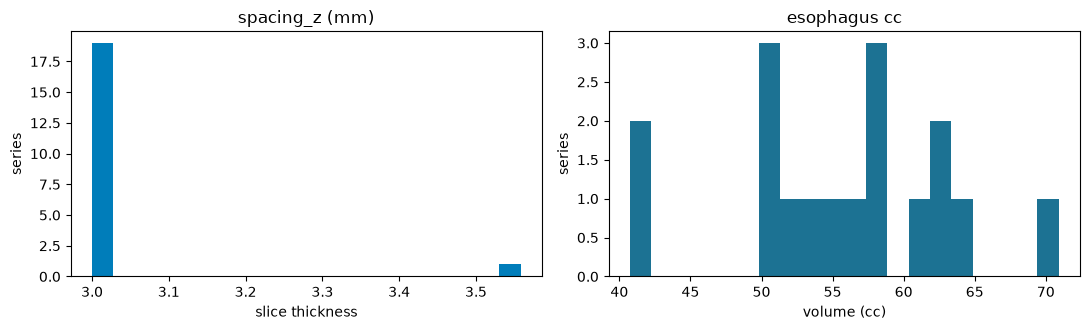

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

# (a) slice-thickness distribution
axes[0].hist(manifest["spacing_z"].dropna(), bins=20, color="#007DBA")
axes[0].set_title("spacing_z (mm)")
axes[0].set_xlabel("slice thickness"); axes[0].set_ylabel("series")

# (b) volume distribution for the first ROI that has data
vol_col = next((c for c in cc_cols if manifest[c].notna().sum() > 1), None)
if vol_col:
    axes[1].hist(manifest[vol_col].dropna(), bins=20, color="#1C7293")
    axes[1].set_title(f"{vol_col}")
    axes[1].set_xlabel("volume (cc)"); axes[1].set_ylabel("series")
plt.tight_layout(); plt.show()

In [9]:
def flag_outliers(series, k=1.5):
    # Boolean mask of IQR outliers: values beyond k*IQR below Q1 or above Q3.
    s = series.dropna()
    if len(s) < 4:
        return pd.Series(False, index=series.index)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (series < lo) | (series > hi)

# Flag geometry + volume outliers so you can review or exclude them before converting.
report = manifest[["patient_hash", "series_hash", "spacing_z"] + cc_cols].copy()
report["spacing_z_outlier"] = flag_outliers(manifest["spacing_z"])
for c in cc_cols:
    report[c + "_outlier"] = flag_outliers(manifest[c])

flagged = report[report.filter(like="_outlier").any(axis=1)]
print(f"{len(flagged)} series flagged for review")
flagged.head(20)

3 series flagged for review


,patient_hash,series_hash,spacing_z,esophagus cc,gtv-1 cc,gtv-2 cc,gtv-3 cc,gtv-4 cc,heart cc,lung-left cc,...,spacing_z_outlier,esophagus cc_outlier,gtv-1 cc_outlier,gtv-2 cc_outlier,gtv-3 cc_outlier,gtv-4 cc_outlier,heart cc_outlier,lung-left cc_outlier,lung-right cc_outlier,spinal-cord cc_outlier
0,LUNG1-014,1.3.6.1.4.1.32722.99.99.1511326668641413128656...,3.55814,63.247,12.865,NaN,NaN,NaN,786.550,2790.167,...,True,False,False,False,False,False,False,False,False,False
1,LUNG1-002,1.3.6.1.4.1.32722.99.99.2329880015517990803358...,3.00000,62.449,368.707,NaN,NaN,NaN,1089.288,2012.641,...,False,False,True,False,False,False,False,False,False,False
4,LUNG1-013,1.3.6.1.4.1.32722.99.99.1122879543978731194965...,3.00000,NaN,15.512,NaN,NaN,NaN,NaN,2342.548,...,False,False,False,False,False,False,False,False,False,True


---
## 5 · Select ROIs & normalize their names

Real ROI names are inconsistent across a cohort (`Lung-Left`, `lung_l`, `left lung`).
`ROIAssociationClass` maps aliases onto one canonical name;
`set_contour_names_and_associations` picks the ROIs you actually want. Adjust the aliases
to whatever `return_rois()` printed above.


In [10]:
reader.set_contour_names_and_associations(
    contour_names=["gtv", "lung_l", "lung_r", "esophagus", "heart", "cord"],
    associations=[
        ROIAssociationClass("gtv",       ["gtv-1", "gtv1", "gtv"]),
        ROIAssociationClass("lung_l",    ["lung-left", "lung_l", "left lung"]),
        ROIAssociationClass("lung_r",    ["lung-right", "lung_r", "right lung"]),
        ROIAssociationClass("esophagus", ["esophagus"]),
        ROIAssociationClass("heart",     ["heart"]),
        ROIAssociationClass("cord",      ["spinal-cord", "spinalcord", "spinal cord"]),
    ],
)

# Which series carry the selected ROIs?
print("Series with the selected ROIs:", reader.indexes_with_contours)

2026-07-06 10:39:21,456:INFO:Index 0 at C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.10712.1597260629.793 lacks ['gtv', 'lung_l', 'lung_r', 'esophagus', 'heart', 'cord']. Found: []
2026-07-06 10:39:21,457:INFO:Index 1 at C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.11436.1597260561.739 lacks ['gtv', 'lung_l', 'lung_r', 'esophagus', 'heart', 'cord']. Found: []
2026-07-06 10:39:21,457:INFO:Index 2 at C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.11504.1597260515.421 lacks ['gtv', 'lung_l', 'lung_r', 'esophagus', 'heart', 'cord']. Found: []
2026-07-06 10:39:21,457:INFO:Index 3 at C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.11644.1597260534.485 lacks ['gtv', 'lung_l', 'lung_r', 'esophagus', 'heart', 'cord']. Found: []
2026-07-06 10:39:21,

Series with the selected ROIs: [21, 24, 26, 28, 29, 30, 31, 34, 36, 37, 38, 39]


---
## 6 · Set the output voxel size

The survey showed native spacing varies. Pick **one** target so every case lands on the
same grid (slide: *Choosing an output voxel size*).

- **Isotropic** `(1.0, 1.0, 1.0)` — uniform, model-friendly, larger arrays.
- **Preserve native-ish** `(0.98, 0.98, 3.0)` — smaller, but mixed geometry.

`write_to_folder` applies the rule automatically: **Linear** for image and dose,
**Nearest-neighbour** for masks (never blur a label). Dose lands on the resampled image grid.


In [11]:
OUTPUT_SPACING = (1.0, 1.0, 3.0)   # (x, y, z) in mm — set to None to keep native spacing

# The public resampling helpers, if you ever need them directly:
# from DicomRTTool import resample_to_spacing, resample_to_reference
print("Target voxel size (mm):", OUTPUT_SPACING)

Target voxel size (mm): (1.0, 1.0, 3.0)


---
## 7 · Preserve clinical metadata

Pixels alone aren't research-ready. Ask the reader to pull extra DICOM tags by name;
they're written to a **`metadata.json`** beside every exported series, keyed to the
anonymized ID (slide: *Preserving clinical metadata*).

SITK image tags use `"group|element"` strings. We pull only non-identifying tags here —
the values are written verbatim, so never pull `PatientName`/`PatientID` into an
anonymized export.


In [12]:
EXTRA_TAGS = {
    "PatientAge":            "0010|1010",
    "PatientSex":            "0010|0040",
    "Manufacturer":          "0008|0070",
    "ManufacturerModelName": "0008|1090",
    "KVP":                   "0018|0060",
    "SliceThickness":        "0018|0050",
}

# Rebuild the reader with the same ROI selection *plus* the extra tags and anonymization.
reader = DicomReaderWriter(
    Contour_Names=["gtv", "lung_l", "lung_r", "esophagus", "heart", "cord"],
    associations=[
        ROIAssociationClass("gtv",       ["gtv-1", "gtv1", "gtv"]),
        ROIAssociationClass("lung_l",    ["lung-left", "lung_l", "left lung"]),
        ROIAssociationClass("lung_r",    ["lung-right", "lung_r", "right lung"]),
        ROIAssociationClass("esophagus", ["esophagus"]),
        ROIAssociationClass("heart",     ["heart"]),
        ROIAssociationClass("cord",      ["spinal-cord", "spinalcord", "spinal cord"]),
    ],
    image_sitk_string_keys=EXTRA_TAGS,
    require_all_contours=False,   # keep series that carry only some of the ROIs
)
reader.walk_through_folders(str(DICOM_DIR))
print("Reader ready. Series with contours:", reader.indexes_with_contours)

2026-07-06 10:39:21,491:INFO:Contour names or associations changed, resetting mask
Loading DICOM files:   0%|          | 0/60 [00:00<?, ?it/s]2026-07-06 10:39:21,537:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.10712.1597260629.793
2026-07-06 10:39:21,541:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.11436.1597260561.739
2026-07-06 10:39:21,545:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.11504.1597260515.421
2026-07-06 10:39:21,548:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.11644.1597260534.485
2026-07-06 10:39:21,549:INFO:Loading from C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\dicom\1.2.276.0.7230010.3.1.3.2323910823.12536.1597260637.68

Reader ready. Series with contours: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


---
## 8 · Convert to NIfTI — one call

`write_to_folder` exports every selected series to a tidy per-case tree: resampled
image, one mask per ROI, dose (if present), and the `metadata.json` — plus a cohort
`manifest.csv` and, because we anonymize, an `anonymization_key.json` (slide: *DICOM → NIfTI in one call*).


In [13]:
reader.write_to_folder(
    str(OUT_DIR),
    output_spacing=OUTPUT_SPACING,       # resample on the way out
    anonymize=True,
    salt="AAPM2026-NSCLC",               # deterministic SHA-256 hashing
)
print("Exported to:", OUT_DIR)

Writing to folder...:   0%|          | 0/20 [00:00<?, ?it/s]2026-07-06 10:39:30,138:INFO:Contour names or associations changed, resetting mask
2026-07-06 10:39:30,141:INFO:Contour names or associations changed, resetting mask
2026-07-06 10:39:30,142:INFO:Contour names or associations changed, resetting mask
2026-07-06 10:39:30,147:INFO:Contour names or associations changed, resetting mask
2026-07-06 10:39:30,148:INFO:Contour names or associations changed, resetting mask
2026-07-06 10:39:30,148:INFO:Contour names or associations changed, resetting mask
2026-07-06 10:39:30,149:INFO:Contour names or associations changed, resetting mask
2026-07-06 10:39:30,152:INFO:Contour names or associations changed, resetting mask
2026-07-06 10:39:30,155:INFO:Contour names or associations changed, resetting mask
2026-07-06 10:40:06,027:INFO:Contour names or associations changed, resetting mask
Writing to folder...: 100%|██████████| 20/20 [01:18<00:00,  3.94s/it]

Exported to: C:\Users\BRA008\Modular_Projects\Presentations\2026_AAPM\aapm_nsclc\nifti


In [14]:
# Show the resulting tree (first couple of levels).
def show_tree(root: Path, max_files=6, prefix=""):
    entries = sorted(root.iterdir())
    dirs  = [e for e in entries if e.is_dir()]
    files = [e for e in entries if e.is_file()]
    for f in files[:max_files]:
        print(prefix + f.name)
    for d in dirs:
        print(prefix + d.name + "/")
        show_tree(d, max_files, prefix + "    ")

show_tree(OUT_DIR)

anonymization_key.json
manifest.csv
P0c2ef36d55/
    ST2e82a7fd7166/
        SE73dee5c80eef/
            image.nii.gz
            metadata.json
            masks/
                cord.nii.gz
                esophagus.nii.gz
                gtv.nii.gz
                heart.nii.gz
                lung_l.nii.gz
                lung_r.nii.gz
P0ce4bf1dbe/
    STd1b264a1bed0/
        SE5fce4f9fefc0/
            image.nii.gz
            metadata.json
            masks/
                cord.nii.gz
                esophagus.nii.gz
                gtv.nii.gz
                heart.nii.gz
                lung_l.nii.gz
                lung_r.nii.gz
P23277390b4/
    STef21404142af/
        SE193e46e3d860/
            image.nii.gz
            metadata.json
            masks/
                cord.nii.gz
                esophagus.nii.gz
                gtv.nii.gz
                heart.nii.gz
                lung_l.nii.gz
                lung_r.nii.gz
P310803c9b9/
    ST4f64db197b53/
        SEe425ee485

---
## 9 · Verify an exported case

Load one exported image and a mask, confirm they share geometry (same size / spacing
after resampling), and preview a slice with the GTV overlaid.


In [15]:
import SimpleITK as sitk

# Find the first exported case that has an image + at least one mask.
cases = [p.parent for p in OUT_DIR.rglob("image.nii.gz")]
assert cases, "No exported images found — re-run section 8."
case = cases[0]
print("Inspecting:", case.relative_to(OUT_DIR))

img = sitk.ReadImage(str(case / "image.nii.gz"))
print("Image size   :", img.GetSize())
print("Image spacing:", tuple(round(s, 3) for s in img.GetSpacing()))

mask_files = sorted((case / "masks").glob("*.nii.gz")) if (case / "masks").exists() else []
print("Masks        :", [m.stem.replace('.nii','') for m in mask_files])

# Peek at the metadata sidecar
meta_path = case / "metadata.json"
if meta_path.exists():
    import json as _json
    print("\nmetadata.json:")
    print(_json.dumps(_json.loads(meta_path.read_text()), indent=2)[:600])

Inspecting: P0c2ef36d55\ST2e82a7fd7166\SE73dee5c80eef
Image size   : (501, 501, 107)
Image spacing: (1.0, 1.0, 3.0)
Masks        : ['cord', 'esophagus', 'gtv', 'heart', 'lung_l', 'lung_r']

metadata.json:
{
  "PatientSex": "M ",
  "Manufacturer": "CMS, Inc. ",
  "ManufacturerModelName": "XiO ",
  "KVP": "",
  "SliceThickness": "3.00000 "
}


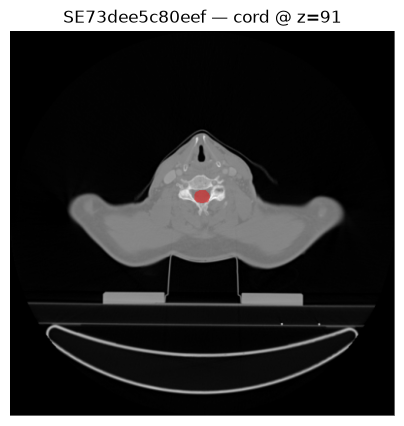

In [16]:
# Overlay the first mask on the image at the slice where the mask is largest.
if mask_files:
    arr  = sitk.GetArrayFromImage(img)                       # (z, y, x)
    mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_files[0])))
    z = int(np.argmax(mask.sum(axis=(1, 2)))) if mask.any() else arr.shape[0] // 2

    plt.figure(figsize=(5, 5))
    plt.imshow(arr[z], cmap="gray")
    plt.imshow(np.ma.masked_where(mask[z] == 0, mask[z]), cmap="autumn", alpha=0.45)
    plt.title(f"{case.name} — {mask_files[0].stem.replace('.nii','')} @ z={z}")
    plt.axis("off"); plt.show()
else:
    print("No masks exported for this case.")

---
## 10 · Grow the dataset over time

The `anonymization_key.json` maps each study hash back to its MRN — **stored securely,
never traveling with the data**. Because the hashing is deterministic (same `salt` →
same hash), you can re-pull the same patients later and fold new imaging or follow-up in
without re-identifying anything.

`create_manifest` is **incremental**: point it at an existing manifest and it *upserts*
by `series_hash` — existing rows are updated, new series appended — so one manifest can
grow across many walks.

```python
# Later, after downloading more patients into DICOM_DIR:
reader.reset()
reader.walk_through_folders(str(DICOM_DIR))
reader.create_manifest(str(MANIFEST))   # updates the same file in place
```

### Where this goes next
- **Session 2** builds reproducible PyTorch pipelines on this exact NIfTI dataset.
- **Session 3** covers integrating and monitoring models in the clinic.

**Tool:** <https://github.com/brianmanderson/Dicom_RT_and_Images_to_Mask> · `pip install DicomRTTool`
